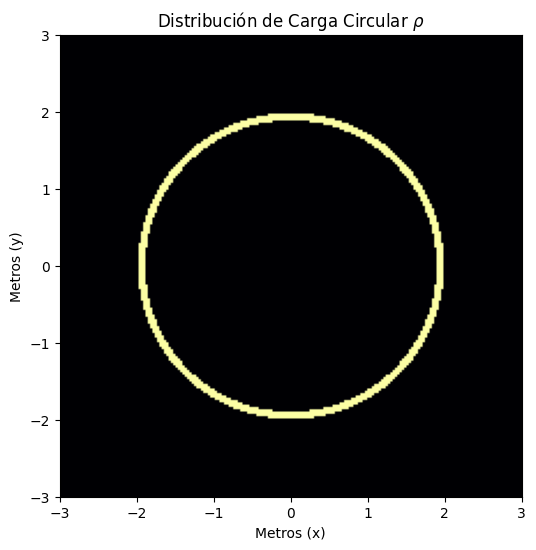

In [ ]:
# Librerias
import numpy as np
import matplotlib.pyplot as plt



metros = 5 # Unidad de cada espacio
Lx,Ly = 1.2 * metros, 1.2 * metros # Unidad fisica de cada espacio

# Tamaño de la malla
Mx,My = 200,200

dx, dy = Lx / (Mx - 1), Ly / (My - 1) # diferenciales de distancia de la maya (creo q era algo asi)
h = dx
e_0 = 8.8541878128e-12  # F/m (Faradios por metro) pd: igual no lo uso, solo lo tengo ahí para un futuro


# Se crean los arrays uniformemente espaciados
x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)

# Hace que los arrays de 1D los junte en uno de 2D
X,Y = np.meshgrid(x,y)

# Formula del radio del circulo aplico al meshgrid
R = np.sqrt(X**2 + Y**2)

# Caso circulo (si quieres verlo, descomenta los 2 de abajo y comenta la sección del anillo)
# radius_circle = 2
# mask_circle = R <= radius_circle

# Caso anillo 
r_out = 2 # metros
r_in = 1.9 # metros
mask_ring = (R <= r_out) & (R >= r_in) 

# Genera la densidad del mismo tamaño de la maya 
rho = np.zeros((My, Mx))

# Valor arbitrario de la carga
Q = 1e-9 # Coulomb

# A la densidad se le aplica el filtro para que de la forma del circulo
rho[mask_ring] = Q

# Figura cuadrada
plt.figure(figsize=(6,6))
# Titulo 
plt.title(r"Distribución de Carga Circular $\rho$")
# Se usa extent para que los ejes sean metros reales
plt.imshow(rho, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='inferno')
plt.xlabel('Metros (x)')
plt.ylabel('Metros (y)')
# Quitamos la rejilla para que se vea más limpio
plt.grid(False)
plt.show()

<Figure size 600x600 with 0 Axes>

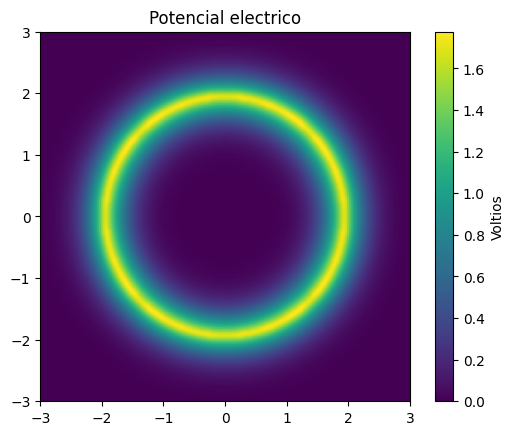

In [8]:
# Discretizacion:

# Potencial inicial
phi = np.zeros((Mx,My))
# Se aplica las diferencias finitas usando vectorización (Es menos tardado y optimo que usando 2 ciclos for) ((recordar que estamos en cartesianas))
for _ in range(400):
    phi[1:-1,1:-1] = 1/4*(phi[1:-1,2:] + phi[1:-1,:-2] + phi[2:,1:-1] + phi[:-2,1:-1] + (h**2 * rho[1:-1,1:-1])/e_0 )

plt.figure(figsize=(6,6))

fig,ax = plt.subplots(1,1)
p = ax.imshow(phi,extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin="lower",cmap="viridis")
ax.set_title("Potencial electrico")
plt.colorbar(p,ax=ax,label="Voltios")

In [ ]:
# Segunda versión con la convergencia mencionada

tolerancia = 1e-5
error = 1
i = 0
max_i = 10000

while error > tolerancia and i < max_i:
    phi_old = phi.copy()

    phi[1:-1,1:-1] = 1/4*(phi[1:-1,2:] + phi[1:-1,:-2] + phi[2:,1:-1] + phi[:-2,1:-1] + (h**2 * rho[1:-1,1:-1])/e_0 )

    error = np.max(np.abs(phi - phi_old))

    i += 1
    
print(f"Convergencia en {i} iteraciones.")
print(f"Error acumulado final: {error:.2e}")

# El error que muestra no es muy bueno la vdd, por lo tanto se usará otro

 Convergencia en 10000 iteraciones.
Error acumulado final: 4.99e-04


In [ ]:
# --- Parámetros de Convergencia y SOR ---
 # Factor de aceleración (viene de la formula del SOR)
omega = 1.9
tolerancia = 1e-5
error = 1.0
iteraciones = 0
max_iter = 10000
# Se crea una matriz de coordenadas de I x J
I, J = np.indices(phi.shape)

# Se realizan mascaras booleanas para determinar los puntos rojos y negros de este tablero de ajedrez 
interior = np.zeros_like(phi, dtype=bool)
# Bordes a 0 V
interior[1:-1, 1:-1] = True # Protegemos los bordes (0V)

mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error > tolerancia and iteraciones < max_iter:
    # Se genera una copia de los datos anteriores para medir el error final
    phi_old = phi.copy()
    
    # Se actualizan las casillas rojas
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Se aplica el SOR a las casillas rojas
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    

    # Se re-calcula los promedios considerando las casillas rojas
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Se aplica solo a las casillas negras
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    # Finalmente se mide el error y aumenta la iteración
    error = np.max(np.abs(phi - phi_old))
    iteraciones += 1

print(f"Convergencia en {iteraciones} iteraciones.")
print(f"Error acumulado final: {error:.2e}")




Convergencia en 1 iteraciones.
Error acumulado final: 9.91e-06


<Figure size 600x600 with 0 Axes>

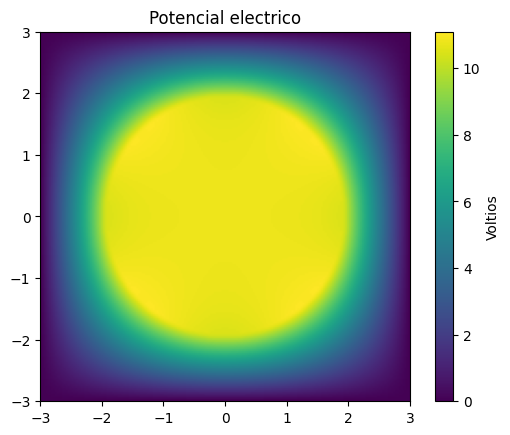

In [ ]:
# Potencial inicial
# phi = np.zeros((Mx,My))
# # Se aplica las diferencias finitas usando vectorización (Es menos tardado y optimo que usando 2 ciclos for) ((recordar que estamos en cartesianas))
# for _ in range(400):
#     phi[1:-1,1:-1] = 1/4*(phi[1:-1,2:] + phi[1:-1,:-2] + phi[2:,1:-1] + phi[:-2,1:-1] + (h**2 * rho[1:-1,1:-1])/e_0 )

# Se usa el nuevo potencial obtenido con SOR 
plt.figure(figsize=(6,6))

fig,ax = plt.subplots(1,1)
p = ax.imshow(phi,extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin="lower",cmap="viridis")
ax.set_title("Potencial electrico")
plt.colorbar(p,ax=ax,label="Voltios")

Calculando Campo Eléctrico...


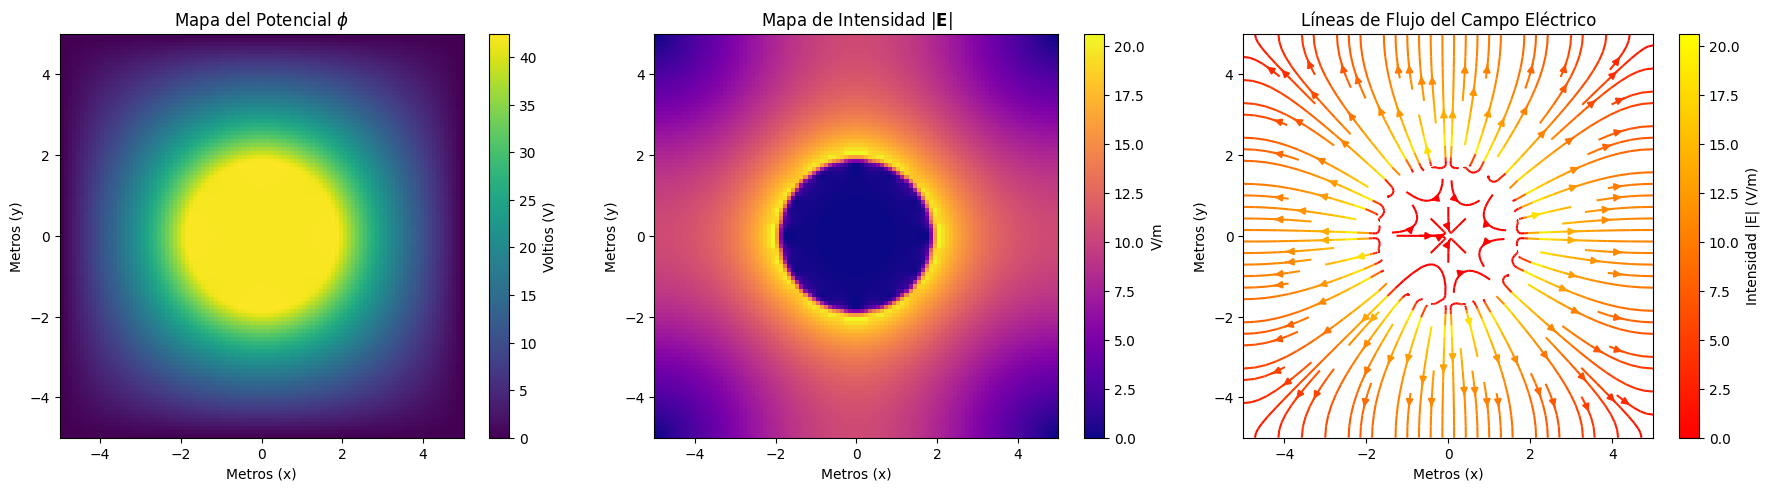

In [ ]:
# Calculo del campo eléctrico por medio de numpy 

Ey, Ex = np.gradient(-phi, dy, dx)

# Calculo del modulo del campo electrico
E_mag = np.sqrt(Ex**2 + Ey**2)



# Se crea una figura con 3 subgráficos (1 fila, 3 columnas)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Parte del mapa del potencial
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Parte del mapa de intensidad del campo electrico
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma')
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Lineas del flujo del campo electrico, usando streamplot, pasando la magnitud del campo electrico como color para mejor visualizacion
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.2, linewidth=1.5)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()